# Essay I — Panel Pipeline

Builds a firm-year panel from the Thesis 3 (or Thesis 2) variance decomposition and quarterly firm controls, then estimates firm + year fixed-effects regressions and saves a standard regression output table.

In [255]:
import sys
from pathlib import Path

# Add Scripts folder so local modules resolve correctly.
SCRIPTS_DIR = Path(".").resolve()
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

import numpy as np
import pandas as pd
from linearmodels.panel import PanelOLS
pd.set_option("display.float_format", "{:.6f}".format)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

PROJECT_DIR = SCRIPTS_DIR.parent
DATA_DIR    = PROJECT_DIR / "Data"
OUTPUTS_DIR = PROJECT_DIR / "Outputs" / "essay1_pipeline"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

# Import daily-sheet helpers directly (parse_data_workbook also loads quarterly_,
# which has a non-standard format — we parse each sheet separately below).
from data_interface import (read_bloomberg_two_row_sheet,
                             split_price_volume,
                             build_daily_canonical_panel)
from Thesis_3_core import run_thesis3_from_daily_panel
from Thesis_2    import run_thesis2_from_daily_panel

print("Imports OK")
print(f"PROJECT_DIR : {PROJECT_DIR}")


Imports OK
PROJECT_DIR : /Users/docx/VCS/Thesis


## Configuration

Edit `OUTCOME_VARS` and `CONTROL_VARS` to change what the regression estimates. All other settings are also here.

In [256]:
# ================================================================
# REGRESSION CONFIGURATION — edit these to set up your analysis
# ================================================================

# Switch between models here — OUTCOME_VARS is set automatically.
#   thesis3 produces: PrivateInfoShare, PublicInfoShare, MktInfoShare, NoiseShare
#   thesis2 produces: FirmInfoShare,    MktInfoShare,    NoiseShare
DECOMP_MODEL = "thesis2"   # "thesis3" or "thesis2"

_outcomes_by_model = {
    "thesis3": ["PrivateInfoShare", "PublicInfoShare", "MktInfoShare", "NoiseShare"],
    "thesis2": ["FirmInfoShare", "MktInfoShare", "NoiseShare"],
}
OUTCOME_VARS: list = _outcomes_by_model[DECOMP_MODEL]

# Independent variables (Step 2b creates the transformed columns).
# Three prefixes are supported and applied automatically:
#   L1_<VAR>  -> one-year lag                X_{i,t-1}
#   D_<VAR>   -> one-year first difference   X_{i,t} - X_{i,t-1}
#   <VAR>     -> contemporaneous level       X_{i,t}
# Under firm FE, levels of a persistent variable (e.g. Bloomberg ESG) carry
# very little within-firm variation. Using D_ESG_SCORE makes the within-firm
# year-on-year change the source of identification.
#
# Base yearly variables available (coverage):
#   BS_TOT_ASSET 97.7%  PROF_MARGIN 97.6%  ASSET_TURNOVER 96.7%
#   HEADLINE_CAPEX 96.7%  FNCL_LVRG 96.2%  RETURN_COM_EQY 96.1%
#   HEADLINE_BVPS 95.7%  ESG_DISCLOSURE_SCORE 94.4%  CUR_MKT_CAP 93.6%
#   PCT_INSIDER_SHARES_OUT 92.3%  GOVERNANCE_SCORE 89.6%
#   ESG_SCORE 87.8%  ENVIRONMENTAL_SCORE 87.8%  SOCIAL_SCORE 87.8%
#   FREE_CASH_FLOW_PER_SH 87.4%  BS_ST_BORROWING_CB 69.1% REALISED_VOL (100%)
CONTROL_VARS: list = [
    "D_ESG_SCORE",
    "L1_LOG_MKT_CAP",
    "L1_REALISED_VOL"
]

# Tag appended to output filenames so robustness runs don't overwrite the
# main results. Set to "" to overwrite.
RUN_TAG = "_dESG"

# ---- pipeline settings ----
START_YEAR      = 2015
END_YEAR        = 2025
DATA_FILE       = DATA_DIR / "data.xlsx"
DAILY_SHEET     = "daily_"
YEARLY_SHEET    = "yearly_"
MARKET_TICKER   = "SXXP Index"
MAX_STOCKS      = None               # set e.g. to 20 for a quick smoke test

# Set True to ignore cached results and recompute from raw data.
# Required after updating data.xlsx or changing DECOMP_MODEL for the first time.
FORCE_RECOMPUTE = False

# ================================================================
print(f"Y      : {OUTCOME_VARS}")
print(f"X      : {CONTROL_VARS}")
print(f"Model  : {DECOMP_MODEL}  |  {START_YEAR}–{END_YEAR}  |  tag: '{RUN_TAG}'")
print(f"Stocks : {'all' if MAX_STOCKS is None else MAX_STOCKS}")
print(f"Cache  : {'DISABLED (FORCE_RECOMPUTE=True)' if FORCE_RECOMPUTE else 'enabled'}")

Y      : ['FirmInfoShare', 'MktInfoShare', 'NoiseShare']
X      : ['D_ESG_SCORE', 'L1_LOG_MKT_CAP', 'L1_REALISED_VOL']
Model  : thesis2  |  2015–2025  |  tag: '_dESG'
Stocks : all
Cache  : enabled


## Helper functions

In [257]:
def _safe_numeric(s):
    return pd.to_numeric(s, errors="coerce")


def standardize_decomposition_output(raw_results, decomp_model):
    df = raw_results.copy()
    if "period" in df.columns and "year" not in df.columns:
        df["year"] = pd.to_numeric(df["period"], errors="coerce")
    df["year"] = pd.to_numeric(df["year"], errors="coerce")
    df["decomp_model"] = decomp_model
    df["noise_share_proxy"] = pd.to_numeric(df["NoiseShare"], errors="coerce") if "NoiseShare" in df.columns else np.nan
    if "VarTotal" in df.columns:
        df["total_var"] = pd.to_numeric(df["VarTotal"], errors="coerce")
    elif "TotalVar" in df.columns:
        df["total_var"] = pd.to_numeric(df["TotalVar"], errors="coerce")
    else:
        df["total_var"] = np.nan
    for col in ["MktInfoShare", "FirmInfoShare", "PrivateInfoShare", "PublicInfoShare", "NoiseShare"]:
        if col not in df.columns:
            df[col] = np.nan
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df["FirmInfoShareAgg"] = (df["PrivateInfoShare"] + df["PublicInfoShare"]) if decomp_model == "thesis3" else np.nan
    base = ["stock","year","decomp_model","noise_share_proxy","total_var",
            "MktInfoShare","FirmInfoShare","PrivateInfoShare","PublicInfoShare","FirmInfoShareAgg","NoiseShare"]
    other = [c for c in df.columns if c not in base]
    return df[base + other].copy()


def apply_sample_filters(panel_df, start_year, end_year):
    df = panel_df.copy()
    df = df[df["year"].between(start_year, end_year, inclusive="both")]
    for col in ["MktInfoShare","FirmInfoShare","PrivateInfoShare","PublicInfoShare","FirmInfoShareAgg","NoiseShare"]:
        valid = df[col].isna() | ((df[col] >= 0) & (df[col] <= 100))
        df = df[valid]
    df = df[df["noise_share_proxy"].notna()]
    if "total_var" in df.columns:
        df = df[(df["total_var"].isna()) | (df["total_var"] > 0)]
    return df.reset_index(drop=True)


print("Helper functions defined")

Helper functions defined


## Regression functions

In [258]:
def _fit_clustered_fe_panel(df, outcome_col, control_cols):
    yearly_cols = [f"{c}_y" for c in control_cols if f"{c}_y" in df.columns]
    reg_df = df[["stock","year",outcome_col] + yearly_cols].copy()
    for col in [outcome_col] + yearly_cols:
        reg_df[col] = pd.to_numeric(reg_df[col], errors="coerce")
    reg_df = reg_df.dropna()

    _empty = dict(outcome=outcome_col, controls=control_cols,
                  n_obs=0, n_stocks=0, n_years=0,
                  multiple_r=np.nan, r_square=np.nan, adj_r_square=np.nan,
                  std_error_regression=np.nan,
                  df_reg=np.nan, df_resid=np.nan, df_total=np.nan,
                  ss_reg=np.nan, ss_resid=np.nan, ss_total=np.nan,
                  ms_reg=np.nan, ms_resid=np.nan,
                  f_stat=np.nan, f_pval=np.nan, coef_table=[], error=None)

    if len(reg_df) == 0 or reg_df["stock"].nunique() < 2 or reg_df["year"].nunique() < 2:
        _empty.update(n_obs=int(len(reg_df)),
                      n_stocks=int(reg_df["stock"].nunique()) if len(reg_df) > 0 else 0,
                      n_years=int(reg_df["year"].nunique()) if len(reg_df) > 0 else 0,
                      error="Insufficient variation for FE estimation.")
        return _empty

    reg_df = reg_df.set_index(["stock","year"]).sort_index()
    y, x = reg_df[outcome_col], reg_df[yearly_cols]

    try:
        fitted = PanelOLS(dependent=y, exog=x,
                          entity_effects=True, time_effects=True,
                          drop_absorbed=True).fit(cov_type="clustered", cluster_entity=True)
        n, k = int(fitted.nobs), len(fitted.params)
        ss_resid  = float((fitted.resids ** 2).sum())
        r2_within = float(fitted.rsquared_within)
        ss_total  = ss_resid / (1.0 - r2_within) if r2_within < 1.0 else np.nan
        ss_reg    = (ss_total - ss_resid) if not np.isnan(ss_total) else np.nan
        df_reg    = k
        df_resid  = int(fitted.df_resid)
        ms_reg    = ss_reg  / df_reg   if df_reg  > 0 and not np.isnan(ss_reg)  else np.nan
        ms_resid  = ss_resid / df_resid if df_resid > 0 else np.nan
        rmse      = float(np.sqrt(ms_resid)) if not np.isnan(ms_resid) else np.nan
        adj_r2    = float(1.0 - (1.0 - r2_within) * (n-1) / (n-k-1)) if (n-k-1) > 0 else np.nan
        try:    f_stat, f_pval = float(fitted.f_statistic.stat), float(fitted.f_statistic.pval)
        except: f_stat, f_pval = np.nan, np.nan
        ci = fitted.conf_int()
        coef_table = [{"variable": v,
                       "coef": float(fitted.params[v]),
                       "se":   float(fitted.std_errors[v]),
                       "t_stat":  float(fitted.tstats[v]),
                       "p_value": float(fitted.pvalues[v]),
                       "lower_95": float(ci.loc[v,"lower"]),
                       "upper_95": float(ci.loc[v,"upper"])} for v in fitted.params.index]
        return dict(outcome=outcome_col, controls=control_cols,
                    n_obs=n, n_stocks=int(reg_df.index.get_level_values(0).nunique()),
                    n_years=int(reg_df.index.get_level_values(1).nunique()),
                    multiple_r=float(np.sqrt(r2_within)), r_square=r2_within,
                    adj_r_square=adj_r2, std_error_regression=rmse,
                    df_reg=df_reg, df_resid=df_resid, df_total=n-1,
                    ss_reg=ss_reg, ss_resid=ss_resid, ss_total=ss_total,
                    ms_reg=ms_reg, ms_resid=ms_resid,
                    f_stat=f_stat, f_pval=f_pval, coef_table=coef_table, error=None)
    except Exception as exc:
        r = dict(_empty)
        r.update(n_obs=int(len(reg_df)),
                 n_stocks=int(reg_df.index.get_level_values(0).nunique()),
                 n_years=int(reg_df.index.get_level_values(1).nunique()),
                 error=str(exc))
        return r


def run_fe_regressions(panel_df, outcome_vars, control_vars):
    available = [c for c in outcome_vars if c in panel_df.columns]
    return [_fit_clustered_fe_panel(panel_df, o, control_vars) for o in available]


def _rows_for_block(result):
    out, controls_str = result["outcome"], " + ".join(f"{c}_y" for c in result["controls"])
    def _f(v, d=6):
        if v is None or (isinstance(v, float) and np.isnan(v)): return ""
        if isinstance(v, (int, np.integer)): return int(v)
        return round(float(v), d)
    rows = []
    rows += [[f"Regression: {out} ~ {controls_str}","","","","","",""],
             ["Model: PanelOLS  |  Entity + time FE  |  Stock-clustered SE","","","","","",""],
             [""]]
    rows += [["Regression Statistics"],
             ["Multiple R",        _f(result["multiple_r"])],
             ["R Square (within)", _f(result["r_square"])],
             ["Adjusted R Square", _f(result["adj_r_square"])],
             ["Standard Error",    _f(result["std_error_regression"])],
             ["Observations",      result["n_obs"]],
             ["Unique stocks",     result["n_stocks"]],
             ["Years",             result["n_years"]]]
    if result.get("error"):
        rows.append(["Note", result["error"]])
    rows.append([""])
    rows += [["ANOVA","","","","",""],
             ["","df","SS","MS","F","Significance F"],
             ["Regression", result["df_reg"],   _f(result["ss_reg"]),   _f(result["ms_reg"]),   _f(result["f_stat"]), _f(result["f_pval"])],
             ["Residual",   result["df_resid"], _f(result["ss_resid"]), _f(result["ms_resid"]), "",""],
             ["Total",      result["df_total"], _f(result["ss_total"]), "","",""],
             [""]]
    rows.append(["","Coefficients","Standard Error","t Stat","P-value","Lower 95%","Upper 95%"])
    for r in result["coef_table"]:
        rows.append([r["variable"],_f(r["coef"]),_f(r["se"]),_f(r["t_stat"]),_f(r["p_value"]),_f(r["lower_95"]),_f(r["upper_95"])])
    rows += [[""],  [""]]
    return rows


def save_regression_table(results, path):
    all_rows = []
    for r in results:
        all_rows.extend(_rows_for_block(r))
    w = max((len(r) for r in all_rows), default=7)
    pd.DataFrame([r + [""]*(w-len(r)) for r in all_rows]).to_csv(path, index=False, header=False)


print("Regression functions defined")


Regression functions defined


## Step 1 — Run variance decomposition

Loads the daily returns panel from `daily_` and runs the selected decomposition model. Takes ~1–2 minutes for the full stock universe.

In [259]:
import time

# Cache paths — decomp is model-specific; realised vol is model-independent.
# Using pickle instead of parquet to avoid a pyarrow extension-type registration
# conflict (ArrowKeyError on second read_parquet call in the same kernel session).
_cache_decomp = OUTPUTS_DIR / f"essay1_decomp_{DECOMP_MODEL}.pkl"
_cache_vol    = OUTPUTS_DIR / "essay1_realised_vol.pkl"

# Only use cache for full runs (MAX_STOCKS=None); smoke-test runs skip it.
_use_cache = (not FORCE_RECOMPUTE) and (MAX_STOCKS is None) \
             and _cache_decomp.exists() and _cache_vol.exists()

if _use_cache:
    print(f"Loading from cache  (set FORCE_RECOMPUTE=True to rerun from scratch)")
    t0 = time.time()
    decomp_results       = pd.read_pickle(_cache_decomp)
    _realised_vol_cached = pd.read_pickle(_cache_vol)
    daily = None   # not needed when both decomp and vol are cached
    ew_df = pd.DataFrame()
    vw_df = pd.DataFrame()
    print(f"  decomp : {len(decomp_results):,} rows, "
          f"{decomp_results['stock'].nunique()} stocks, "
          f"years {int(decomp_results['year'].min())}–{int(decomp_results['year'].max())}"
          f"  ({time.time()-t0:.1f}s)")
    print(f"  vol    : {len(_realised_vol_cached):,} firm-years")

else:
    print("Loading daily_ sheet…")
    t0 = time.time()
    _daily_raw = read_bloomberg_two_row_sheet(DATA_FILE, sheet_name=DAILY_SHEET)
    _parts     = split_price_volume(_daily_raw)
    daily      = build_daily_canonical_panel(_parts["prices"], _parts["volume"],
                                             market_ticker=MARKET_TICKER)
    print(f"  {daily['stock'].nunique()} stocks, {len(daily):,} rows  ({time.time()-t0:.1f}s)")

    if MAX_STOCKS is not None:
        keep  = daily["stock"].drop_duplicates().head(MAX_STOCKS)
        daily = daily[daily["stock"].isin(keep)].copy()
        print(f"  Capped to {daily['stock'].nunique()} stocks (MAX_STOCKS={MAX_STOCKS})")

    # Pre-compute realised vol while daily is in memory.
    _realised_vol_cached = (
        daily
        .assign(log_ret=np.log1p(daily["stock_ret"]))
        .groupby(["stock", "year"])["log_ret"]
        .std()
        .mul(np.sqrt(252))
        .reset_index()
        .rename(columns={"log_ret": "REALISED_VOL_y"})
    )

    print(f"Running {DECOMP_MODEL} decomposition…")
    t1 = time.time()
    if DECOMP_MODEL == "thesis3":
        _decomp_raw = run_thesis3_from_daily_panel(daily)
    else:
        _decomp_raw = run_thesis2_from_daily_panel(daily)

    decomp_results = standardize_decomposition_output(_decomp_raw["results"], DECOMP_MODEL)
    ew_df = _decomp_raw.get("ew", pd.DataFrame())
    vw_df = _decomp_raw.get("vw", pd.DataFrame())
    print(f"  Done in {time.time()-t1:.1f}s — "
          f"{len(decomp_results):,} rows, {decomp_results['stock'].nunique()} stocks, "
          f"years {int(decomp_results['year'].min())}–{int(decomp_results['year'].max())}")

    if MAX_STOCKS is None:
        decomp_results.to_pickle(_cache_decomp)
        _realised_vol_cached.to_pickle(_cache_vol)
        print(f"  Cached → {_cache_decomp.name}  |  {_cache_vol.name}")

decomp_results.head(3)

Loading from cache  (set FORCE_RECOMPUTE=True to rerun from scratch)
  decomp : 6,236 rows, 595 stocks, years 2015–2025  (0.0s)
  vol    : 6,242 firm-years


,stock,year,decomp_model,noise_share_proxy,total_var,MktInfoShare,FirmInfoShare,PrivateInfoShare,PublicInfoShare,FirmInfoShareAgg,...,b10,theta_market,theta_stock,sigma2_eps_market,sigma2_eps_stock,MktInfo,FirmInfo,Noise,TotalVar,period
0,A2A IM Equity,2015,thesis2,10.525099,15727.348001,30.177396,59.297505,NaN,NaN,NaN,...,0.848779,0.656841,0.789604,11000.594458,14957.999822,4746.104124,9325.924904,1655.318973,15727.348001,2015
1,AAK SS Equity,2015,thesis2,7.197274,13407.452809,50.512386,42.290340,NaN,NaN,NaN,...,0.727522,0.778842,0.778138,11164.671464,9364.278851,6772.424379,5670.057367,964.971063,13407.452809,2015
2,AAL LN Equity,2015,thesis2,7.429703,55924.958532,28.393952,64.176345,NaN,NaN,NaN,...,0.982601,1.234271,1.047510,11077.650247,61790.626870,15879.305814,35890.594165,4155.058553,55924.958532,2015


## Step 2 — Load yearly controls

The `yearly_` sheet stores one block of 16 columns per stock (rows 3–4 are ticker/variable headers, rows 5+ are year-end observations). We parse it directly into a long-format firm-year panel and rename columns to the `{VAR}_y` convention expected by the regression functions.

In [260]:
def read_yearly_panel(data_file, sheet_name="yearly_"):
    """
    Parse the yearly_ sheet into a long-format firm-year DataFrame.

    Sheet layout (0-indexed rows):
      0-1  metadata (date range), 2  blank
      3    ticker names (one per 16-column block, rest NaN)
      4    variable names repeated for each block
      5+   year-end observations (date column already parsed as datetime by openpyxl)
    Returns: stock, year, <16 variable columns>.
    """
    raw = pd.read_excel(data_file, sheet_name=sheet_name, header=None)

    vars_per_stock = 16
    var_names  = raw.iloc[4, 1:vars_per_stock + 1].tolist()
    data_start = 5
    n_stocks   = (raw.shape[1] - 1) // vars_per_stock

    # openpyxl converts Excel date cells to Python datetime objects directly;
    # pd.to_datetime handles them without the intermediate numeric conversion.
    dates = pd.to_datetime(raw.iloc[data_start:, 0], errors="coerce")
    years = dates.dt.year.values

    chunks = []
    for s in range(n_stocks):
        ticker = raw.iloc[3, 1 + s * vars_per_stock]
        if pd.isna(ticker):
            continue
        col_start = 1 + s * vars_per_stock
        block = raw.iloc[data_start:, col_start:col_start + vars_per_stock].copy()
        block.columns = var_names
        block["stock"] = ticker
        block["year"]  = years
        chunks.append(block)

    df = pd.concat(chunks, ignore_index=True)
    id_cols = ["stock", "year"]
    df = df[id_cols + [c for c in df.columns if c not in id_cols]]
    for col in var_names:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df.dropna(subset=["year"]).sort_values(["stock", "year"]).reset_index(drop=True)


print("Reading yearly_ data…")
yearly = read_yearly_panel(DATA_FILE, sheet_name=YEARLY_SHEET)

# Attach GICS from the ticker sheet.
ticker_meta = pd.read_excel(DATA_FILE, sheet_name="ticker", index_col=0)
ticker_meta = ticker_meta[["GICS_INDUSTRY_NAME"]].rename(columns={"GICS_INDUSTRY_NAME": "gics_industry_y"})
ticker_meta.index.name = "stock"
yearly = yearly.merge(ticker_meta, on="stock", how="left")

if MAX_STOCKS is not None:
    keep_stocks = decomp_results["stock"].drop_duplicates().head(MAX_STOCKS)
    yearly = yearly[yearly["stock"].isin(keep_stocks)].copy()

# Rename variable columns to the {VAR}_y convention expected downstream.
var_cols = [c for c in yearly.columns if c not in ["stock", "year", "gics_industry_y"]]
controls_yearly = yearly.rename(columns={c: f"{c}_y" for c in var_cols})

print(f"Yearly rows    : {len(yearly):,}  |  stocks: {yearly['stock'].nunique()}")
print(f"Year range     : {int(yearly['year'].min())}–{int(yearly['year'].max())}")
print(f"Controls panel : {len(controls_yearly):,} firm-years, {controls_yearly['stock'].nunique()} stocks")

overlap = set(decomp_results["stock"].unique()) & set(controls_yearly["stock"].unique())
print(f"Overlap (decomp ∩ controls): {len(overlap)} stocks")
controls_yearly.head(3)

Reading yearly_ data…
Yearly rows    : 6,567  |  stocks: 597
Year range     : 2015–2025
Controls panel : 6,567 firm-years, 597 stocks
Overlap (decomp ∩ controls): 595 stocks


,stock,year,CUR_MKT_CAP_y,PCT_INSIDER_SHARES_OUT_y,GOVERNANCE_SCORE_y,ESG_SCORE_y,ENVIRONMENTAL_SCORE_y,SOCIAL_SCORE_y,BS_TOT_ASSET_y,HEADLINE_BVPS_y,PROF_MARGIN_y,ASSET_TURNOVER_y,FNCL_LVRG_y,RETURN_COM_EQY_y,FREE_CASH_FLOW_PER_SH_y,HEADLINE_CAPEX_y,BS_ST_BORROWING_CB_y,ESG_DISCLOSURE_SCORE_y,gics_industry_y
0,A2A IM Equity,2015,3928.663200,0.000000,5.890000,3.970000,4.250000,2.010000,9801.000000,0.851900,1.542700,0.470100,3.853400,2.794300,0.166100,-253.000000,692.000000,56.503400,Multi-Utilities
1,A2A IM Equity,2016,3853.473500,0.000000,6.120000,4.180000,4.550000,2.060000,10387.000000,0.876800,5.064400,0.453800,3.758000,8.637400,0.183000,-259.000000,359.000000,57.448900,Multi-Utilities
2,A2A IM Equity,2017,4830.939500,0.000000,6.460000,4.380000,4.690000,2.250000,9949.000000,0.925600,5.241500,0.549800,3.628800,10.456800,0.180800,-306.000000,437.000000,60.496900,Multi-Utilities


## Step 2b — Transform controls

Three fixed transforms are always applied, then lags / first-differences are generated automatically from `CONTROL_VARS`:

1. **Derived variables** — `LOG_MKT_CAP` and `REALISED_VOL` are computed here and available to any `CONTROL_VAR`.
2. **Winsorise** — variables in `WINSORISE_VARS` are clipped at the 1st / 99th percentile before lagging. Extend that list if you add a heavy-tailed variable.
3. **Auto-transform** — driven entirely by `CONTROL_VARS`:
   - `L1_<VAR>` → one-year lag, column `L1_<VAR>_y`
   - `D_<VAR>`  → one-year first difference (`X_t − X_{t−1}`), column `D_<VAR>_y`
   - `<VAR>`    → contemporaneous level, column `<VAR>_y`

   An explicit `WARNING` is printed if a requested base column is not found.

In [261]:
def winsorise(s, q=0.01):
    lo, hi = s.quantile(q), s.quantile(1 - q)
    return s.clip(lo, hi)


def _resolve_control_column(v):
    """Map a CONTROL_VARS entry to the {prefix}_{VAR}_y column name."""
    if v.startswith("L1_"):
        return f"L1_{v[3:]}_y", f"{v[3:]}_y", "lag"
    if v.startswith("D_"):
        return f"D_{v[2:]}_y", f"{v[2:]}_y", "diff"
    return f"{v}_y", f"{v}_y", "level"


# ── Derived variables ──────────────────────────────────────────────────────────
# Log market cap — replaces raw CUR_MKT_CAP to compress right skew.
controls_yearly["LOG_MKT_CAP_y"] = np.log(controls_yearly["CUR_MKT_CAP_y"].clip(lower=1))

# Realised vol — pre-computed in Step 1 (from daily panel or cache).
controls_yearly = controls_yearly.merge(_realised_vol_cached, on=["stock", "year"], how="left")

# ── Winsorise skewed variables before transforming ─────────────────────────────
WINSORISE_VARS = ["FNCL_LVRG_y", "PROF_MARGIN_y", "REALISED_VOL_y"]
for col in WINSORISE_VARS:
    if col in controls_yearly.columns:
        controls_yearly[col] = winsorise(controls_yearly[col])

# ── Auto-transform: prefix-driven ─────────────────────────────────────────────
controls_yearly = controls_yearly.sort_values(["stock", "year"])
print("Transformation summary  (2015 loses lags/diffs by construction):")
for v in CONTROL_VARS:
    out_col, base_col, kind = _resolve_control_column(v)
    if base_col not in controls_yearly.columns:
        print(f"  WARNING: '{base_col}' not found -- '{out_col}' will be absent from regression")
        continue

    if kind == "lag":
        controls_yearly[out_col] = controls_yearly.groupby("stock")[base_col].shift(1)
        tag = "[lag]"
    elif kind == "diff":
        controls_yearly[out_col] = controls_yearly.groupby("stock")[base_col].diff(1)
        tag = "[Δ]"
    else:
        tag = "[level]"

    n = controls_yearly[out_col].notna().sum()
    print(f"  {out_col:42s}  {n:,}  ({100 * n / len(controls_yearly):.1f}%)  {tag}")

_preview_cols = [_resolve_control_column(v)[0] for v in CONTROL_VARS
                 if _resolve_control_column(v)[0] in controls_yearly.columns]
controls_yearly[["stock", "year"] + _preview_cols].head(5)

Transformation summary  (2015 loses lags/diffs by construction):
  D_ESG_SCORE_y                               5,189  (79.0%)  [Δ]
  L1_LOG_MKT_CAP_y                            5,552  (84.5%)  [lag]
  L1_REALISED_VOL_y                           5,646  (86.0%)  [lag]


,stock,year,D_ESG_SCORE_y,L1_LOG_MKT_CAP_y,L1_REALISED_VOL_y
0,A2A IM Equity,2015,NaN,NaN,NaN
1,A2A IM Equity,2016,0.210000,8.276054,0.277242
2,A2A IM Equity,2017,0.200000,8.256730,0.283191
3,A2A IM Equity,2018,0.240000,8.482796,0.186464
4,A2A IM Equity,2019,0.240000,8.502383,0.222700


## Step 3 — Merge, filter, and regress

In [262]:
merged         = decomp_results.merge(controls_yearly, on=["stock","year"], how="left")
filtered_panel = apply_sample_filters(merged, start_year=START_YEAR, end_year=END_YEAR)

print(f"Merged panel   : {len(merged):,} rows")
print(f"Filtered panel : {len(filtered_panel):,} rows, "
      f"{filtered_panel['stock'].nunique()} stocks, "
      f"{filtered_panel['year'].nunique()} years  "
      f"({int(filtered_panel['year'].min())}–{int(filtered_panel['year'].max())})")

for v in CONTROL_VARS:
    col, _base, _kind = _resolve_control_column(v)
    if col in filtered_panel.columns:
        n = filtered_panel[col].notna().sum()
        print(f"  {col:42s}  {n:,} obs  ({100*n/len(filtered_panel):.1f}%)")
    else:
        print(f"  {col:42s}  NOT IN PANEL")

# Run FE regressions.
results = run_fe_regressions(filtered_panel, OUTCOME_VARS, CONTROL_VARS)

# Save outputs (RUN_TAG keeps robustness runs separate from the main result).
panel_path = OUTPUTS_DIR / f"essay1_panel_{DECOMP_MODEL}{RUN_TAG}.csv"
table_path = OUTPUTS_DIR / f"essay1_regression_table_{DECOMP_MODEL}{RUN_TAG}.csv"
filtered_panel.to_csv(panel_path, index=False)
save_regression_table(results, table_path)

print(f"\nSaved panel          : {panel_path}")
print(f"Saved regression table: {table_path}")

Merged panel   : 6,236 rows
Filtered panel : 6,236 rows, 595 stocks, 11 years  (2015–2025)
  D_ESG_SCORE_y                               5,170 obs  (82.9%)
  L1_LOG_MKT_CAP_y                            5,541 obs  (88.9%)
  L1_REALISED_VOL_y                           5,645 obs  (90.5%)

Saved panel          : /Users/docx/VCS/Thesis/Outputs/essay1_pipeline/essay1_panel_thesis2_dESG.csv
Saved regression table: /Users/docx/VCS/Thesis/Outputs/essay1_pipeline/essay1_regression_table_thesis2_dESG.csv


## Results

## Coefficient plots

Saved: /Users/docx/VCS/Thesis/Outputs/essay1_pipeline/essay1_coef_plot_thesis2_dESG.png


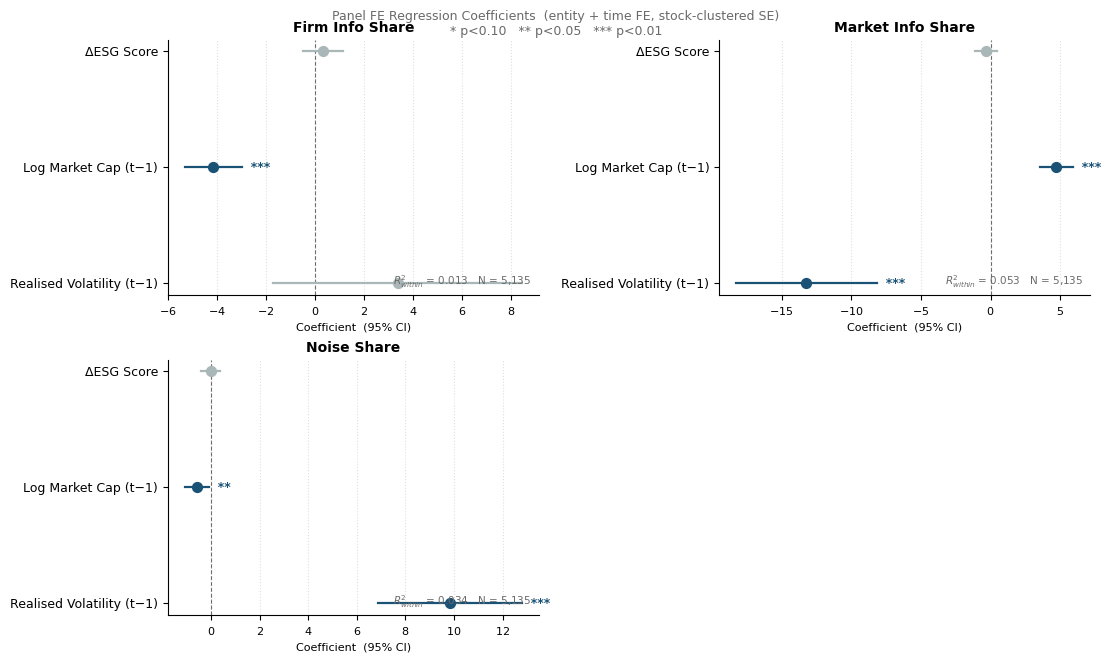

In [263]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── label maps ────────────────────────────────────────────────────────────────
VAR_LABELS = {
    # lagged regressors
    "L1_ESG_SCORE_y":              "ESG Score (t−1)",
    "L1_LOG_MKT_CAP_y":            "Log Market Cap (t−1)",
    "L1_FNCL_LVRG_y":              "Financial Leverage (t−1)",
    "L1_PROF_MARGIN_y":            "Profit Margin (t−1)",
    "L1_REALISED_VOL_y":           "Realised Volatility (t−1)",
    "L1_GOVERNANCE_SCORE_y":       "Governance Score (t−1)",
    "L1_ENVIRONMENTAL_SCORE_y":    "Environmental Score (t−1)",
    "L1_SOCIAL_SCORE_y":           "Social Score (t−1)",
    "L1_RETURN_COM_EQY_y":         "Return on Equity (t−1)",
    "L1_BS_TOT_ASSET_y":           "Log Total Assets (t−1)",
    "L1_PCT_INSIDER_SHARES_OUT_y": "Insider Ownership (t−1)",
    "L1_ESG_DISCLOSURE_SCORE_y":   "ESG Disclosure Score (t−1)",
    # first differences
    "D_ESG_SCORE_y":               "ΔESG Score",
    "D_ESG_DISCLOSURE_SCORE_y":    "ΔESG Disclosure Score",
    "D_GOVERNANCE_SCORE_y":        "ΔGovernance Score",
    "D_ENVIRONMENTAL_SCORE_y":     "ΔEnvironmental Score",
    "D_SOCIAL_SCORE_y":            "ΔSocial Score",
    "D_LOG_MKT_CAP_y":             "Δ Log Market Cap",
}
OUTCOME_LABELS = {
    "PrivateInfoShare": "Private Info Share",
    "PublicInfoShare":  "Public Info Share",
    "FirmInfoShareAgg": "Firm Info Share (agg.)",
    "FirmInfoShare":    "Firm Info Share",
    "MktInfoShare":     "Market Info Share",
    "NoiseShare":       "Noise Share",
}

def _stars(p):
    if p < 0.01:  return "***"
    if p < 0.05:  return "**"
    if p < 0.10:  return "*"
    return ""

def plot_coef_grid(results, save_path=None):
    visible = [r for r in results if r["coef_table"]]
    if not visible:
        print("No results with coefficients to plot.")
        return

    n = len(visible)
    ncols = min(2, n)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(11, 3.2 * nrows),
                             constrained_layout=True)
    axes = np.array(axes).flatten()

    for ax, r in zip(axes, visible):
        rows   = r["coef_table"]
        labels = [VAR_LABELS.get(d["variable"], d["variable"]) for d in rows]
        coefs  = [d["coef"]      for d in rows]
        lows   = [d["lower_95"]  for d in rows]
        highs  = [d["upper_95"]  for d in rows]
        pvals  = [d["p_value"]   for d in rows]

        y_pos = range(len(rows) - 1, -1, -1)

        for y, coef, lo, hi, p in zip(y_pos, coefs, lows, highs, pvals):
            sig   = p < 0.10
            color = "#1a5276" if sig else "#aab7b8"
            ax.plot([lo, hi], [y, y], color=color, lw=1.6, zorder=2)
            ax.scatter([coef], [y], color=color, s=50, zorder=3)
            stars = _stars(p)
            if stars:
                ax.text(hi, y, f"  {stars}", va="center", ha="left",
                        fontsize=9, color="#1a5276", fontweight="bold")

        ax.axvline(0, color="black", lw=0.8, ls="--", alpha=0.6, zorder=1)
        ax.set_yticks(list(y_pos))
        ax.set_yticklabels(labels, fontsize=9)
        ax.tick_params(axis="x", labelsize=8)
        ax.xaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
        ax.ticklabel_format(style="sci", axis="x", scilimits=(-3, 3))

        outcome_label = OUTCOME_LABELS.get(r["outcome"], r["outcome"])
        ax.set_title(outcome_label, fontsize=10, fontweight="bold", pad=6)
        ax.set_xlabel("Coefficient  (95% CI)", fontsize=8)

        r2 = r["r_square"]
        n_obs = r["n_obs"]
        note = f"$R^2_{{within}}$ = {r2:.3f}   N = {n_obs:,}" if not (isinstance(r2, float) and np.isnan(r2)) else f"N = {n_obs:,}"
        ax.text(0.98, 0.02, note, transform=ax.transAxes,
                fontsize=7.5, ha="right", va="bottom", color="dimgray")

        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="x", ls=":", alpha=0.4, zorder=0)

    for ax in axes[len(visible):]:
        ax.set_visible(False)

    fig.suptitle(
        "Panel FE Regression Coefficients  (entity + time FE, stock-clustered SE)\n"
        "* p<0.10   ** p<0.05   *** p<0.01",
        fontsize=9, color="dimgray", y=1.01
    )

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved: {save_path}")

    plt.show()


plot_path = OUTPUTS_DIR / f"essay1_coef_plot_{DECOMP_MODEL}{RUN_TAG}.png"
plot_coef_grid(results, save_path=plot_path)

In [264]:
def _display_block(r):
    out = r["outcome"]
    controls_str = " + ".join(f"{c}_y" for c in r["controls"])
    title = f"Regression: {out} ~ {controls_str}"
    print(f"\n{'='*len(title)}")
    print(title)
    print(f"Model: PanelOLS  |  Entity + time FE  |  Stock-clustered SE")
    print(f"{'='*len(title)}")

    print("\nRegression Statistics")
    for label, val in [
        ("Multiple R",        r["multiple_r"]),
        ("R Square (within)", r["r_square"]),
        ("Adjusted R Square", r["adj_r_square"]),
        ("Standard Error",    r["std_error_regression"]),
        ("Observations",      r["n_obs"]),
        ("Unique stocks",     r["n_stocks"]),
        ("Years",             r["n_years"]),
    ]:
        fmt = f"{val:.6f}" if isinstance(val, float) and not np.isnan(val) else str(val)
        print(f"  {label:<22} {fmt}")
    if r.get("error"):
        print(f"  NOTE: {r['error']}")

    print("\nANOVA")
    anova = pd.DataFrame([
        {"Source":"Regression","df":r["df_reg"],  "SS":r["ss_reg"],  "MS":r["ms_reg"],  "F":r["f_stat"],"Sig.F":r["f_pval"]},
        {"Source":"Residual",  "df":r["df_resid"],"SS":r["ss_resid"],"MS":r["ms_resid"],"F":"",         "Sig.F":""},
        {"Source":"Total",     "df":r["df_total"],"SS":r["ss_total"],"MS":"",            "F":"",         "Sig.F":""},
    ])
    print(anova.to_string(index=False))

    if r["coef_table"]:
        print("\nCoefficients")
        coef_df = pd.DataFrame(r["coef_table"])[
            ["variable","coef","se","t_stat","p_value","lower_95","upper_95"]
        ].rename(columns={"variable":"","coef":"Coeff.",
                          "se":"Std.Err.","t_stat":"t Stat",
                          "p_value":"P-value","lower_95":"Lower 95%","upper_95":"Upper 95%"})
        print(coef_df.to_string(index=False))
    print()


for r in results:
    _display_block(r)



Regression: FirmInfoShare ~ D_ESG_SCORE_y + L1_LOG_MKT_CAP_y + L1_REALISED_VOL_y
Model: PanelOLS  |  Entity + time FE  |  Stock-clustered SE

Regression Statistics
  Multiple R             0.115075
  R Square (within)      0.013242
  Adjusted R Square      0.012665
  Standard Error         11.471059
  Observations           5135
  Unique stocks          577
  Years                  10

ANOVA
    Source   df            SS          MS         F    Sig.F
Regression    3   8027.679425 2675.893142 23.692493 0.000000
  Residual 4546 598186.263797  131.585188                   
     Total 5134 606213.943222                               

Coefficients
                     Coeff.  Std.Err.    t Stat  P-value  Lower 95%  Upper 95%
    D_ESG_SCORE_y  0.337665  0.417717  0.808358 0.418927  -0.481263   1.156593
 L1_LOG_MKT_CAP_y -4.142436  0.601149 -6.890869 0.000000  -5.320979  -2.963893
L1_REALISED_VOL_y  3.380872  2.590389  1.305160 0.191904  -1.697549   8.459292


Regression: MktInfoShare ~ D